In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Attention Matematiği Derinleştirme")
print("=" * 40)
print()
print("Bugün cevaplayacağımız sorular:")
print("1. Neden softmax — başka fonksiyon olmaz mıydı?")
print("2. Neden sqrt(d_k) ile bölüyoruz — gradyan analizi")
print("3. Self-attention türevleri — backprop nasıl çalışır?")
print("4. Causal masking — GPT nasıl gelecek görmüyor?")
print("5. Cross-attention vs self-attention farkı")
print()
print("Anahtar: Transformer'ın her satırının matematiği var!")

torch.manual_seed(42)
np.random.seed(42)

Attention Matematiği Derinleştirme

Bugün cevaplayacağımız sorular:
1. Neden softmax — başka fonksiyon olmaz mıydı?
2. Neden sqrt(d_k) ile bölüyoruz — gradyan analizi
3. Self-attention türevleri — backprop nasıl çalışır?
4. Causal masking — GPT nasıl gelecek görmüyor?
5. Cross-attention vs self-attention farkı

Anahtar: Transformer'ın her satırının matematiği var!


C:\Users\PC\AppData\Local\Temp\ipykernel_15076\2477246969.py:93: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_15076\2477246969.py:93: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


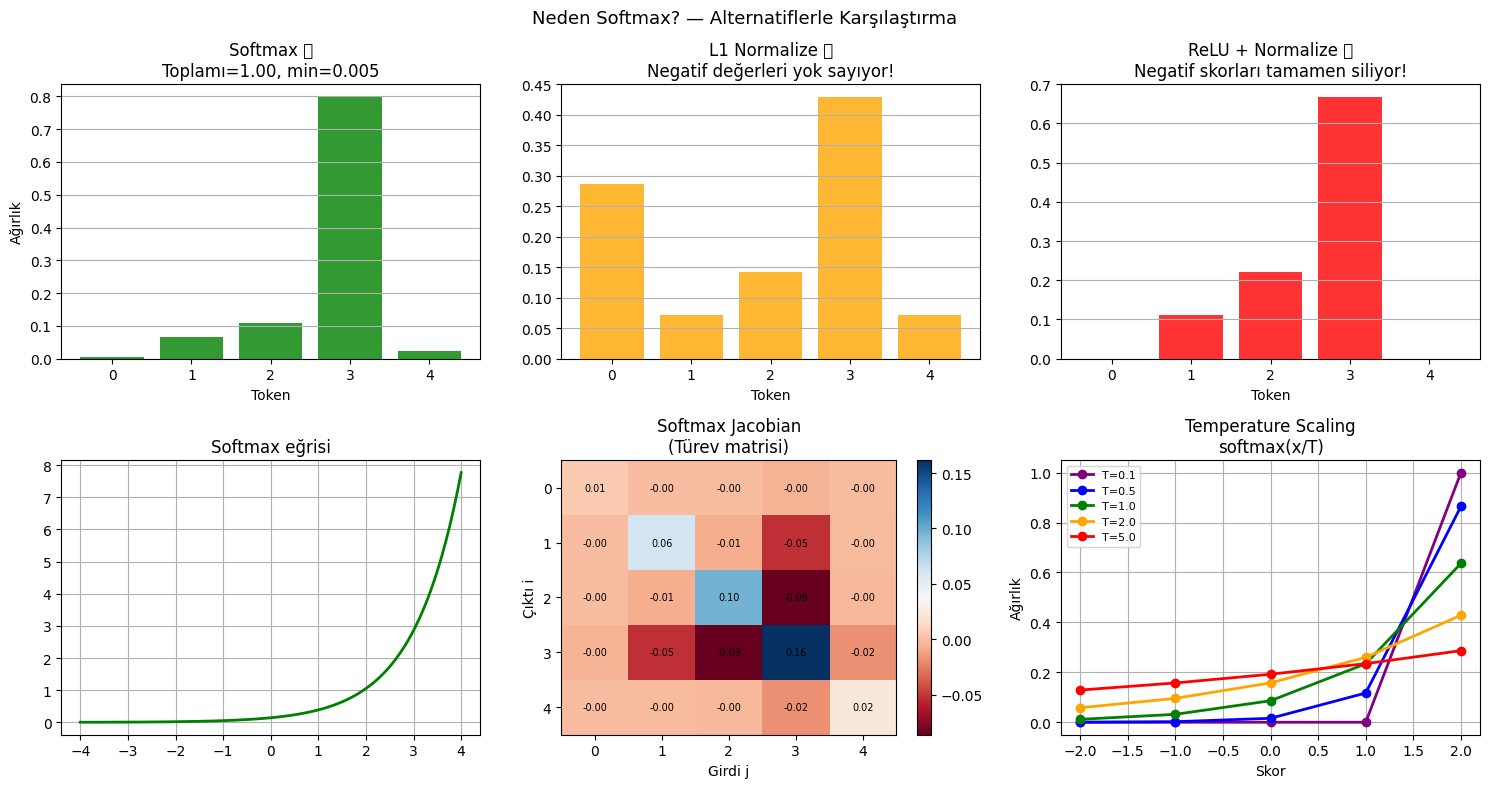

Softmax avantajları:
1. Non-negatif: exp(x) > 0 her zaman
2. Toplamı 1: olasılık dağılımı
3. Differansiable: Jacobian hesaplanabilir
4. Temperature scaling: T ile keskinlik ayarlanır
   T→0: one-hot (çok keskin), T→∞: uniform (çok yumuşak)


In [2]:
# NEDEN SOFTMAX?
#
# Attention ağırlıkları 3 şartı sağlamalı:
# 1. Non-negatif: ağırlık < 0 anlamsız
# 2. Toplamı 1: olasılık dağılımı gibi
# 3. Differansiable: backprop çalışmalı
#
# Alternatifler neden yetersiz?

scores = np.array([-2.0, 0.5, 1.0, 3.0, -0.5])
x_range = np.linspace(-4, 4, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Softmax
def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

softmax_scores = softmax(scores)
axes[0,0].bar(range(len(scores)), softmax_scores, color='green', alpha=0.8)
axes[0,0].set_title(f"Softmax ✅\nToplamı={softmax_scores.sum():.2f}, min={softmax_scores.min():.3f}")
axes[0,0].set_xlabel("Token")
axes[0,0].set_ylabel("Ağırlık")
axes[0,0].grid(True, axis='y')

# Softmax fonksiyonu
axes[1,0].plot(x_range, softmax(x_range.reshape(1,-1)).flatten() * len(x_range),
              'g-', linewidth=2)
axes[1,0].set_title("Softmax eğrisi")
axes[1,0].grid(True)

# 2. Normalize (bölme)
norm_scores = np.abs(scores) / np.abs(scores).sum()
axes[0,1].bar(range(len(scores)), norm_scores, color='orange', alpha=0.8)
axes[0,1].set_title(f"L1 Normalize ❌\nNegatif değerleri yok sayıyor!")
axes[0,1].set_xlabel("Token")
axes[0,1].grid(True, axis='y')

# 3. ReLU + normalize
relu_scores = np.maximum(0, scores)
if relu_scores.sum() > 0:
    relu_norm = relu_scores / relu_scores.sum()
else:
    relu_norm = relu_scores
axes[0,2].bar(range(len(scores)), relu_norm, color='red', alpha=0.8)
axes[0,2].set_title(f"ReLU + Normalize ❌\nNegatif skorları tamamen siliyor!")
axes[0,2].set_xlabel("Token")
axes[0,2].grid(True, axis='y')

# Softmax türevi — neden backprop dostu?
# dSoftmax(i)/dx(j) = S(i) * (δ_ij - S(j))
# Jacobian matrisi

s = softmax(scores)
n = len(s)
jacobian = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            jacobian[i,j] = s[i] * (1 - s[j])
        else:
            jacobian[i,j] = -s[i] * s[j]

im = axes[1,1].imshow(jacobian, cmap='RdBu', aspect='auto')
axes[1,1].set_title("Softmax Jacobian\n(Türev matrisi)")
axes[1,1].set_xlabel("Girdi j")
axes[1,1].set_ylabel("Çıktı i")
plt.colorbar(im, ax=axes[1,1])

for i in range(n):
    for j in range(n):
        axes[1,1].text(j, i, f'{jacobian[i,j]:.2f}',
                      ha='center', va='center', fontsize=7)

# Temperature scaling
axes[1,2].set_title("Temperature Scaling\nsoftmax(x/T)")
temps = [0.1, 0.5, 1.0, 2.0, 5.0]
renkler_t = ['purple', 'blue', 'green', 'orange', 'red']
x_vals = np.array([-2, -1, 0, 1, 2], dtype=float)

for T, renk in zip(temps, renkler_t):
    s_t = softmax(x_vals / T)
    axes[1,2].plot(x_vals, s_t, 'o-', color=renk,
                  linewidth=2, label=f'T={T}')

axes[1,2].legend(fontsize=8)
axes[1,2].set_xlabel("Skor")
axes[1,2].set_ylabel("Ağırlık")
axes[1,2].grid(True)

plt.suptitle("Neden Softmax? — Alternatiflerle Karşılaştırma", fontsize=13)
plt.tight_layout()
plt.show()

print("Softmax avantajları:")
print("1. Non-negatif: exp(x) > 0 her zaman")
print("2. Toplamı 1: olasılık dağılımı")
print("3. Differansiable: Jacobian hesaplanabilir")
print("4. Temperature scaling: T ile keskinlik ayarlanır")
print("   T→0: one-hot (çok keskin), T→∞: uniform (çok yumuşak)")

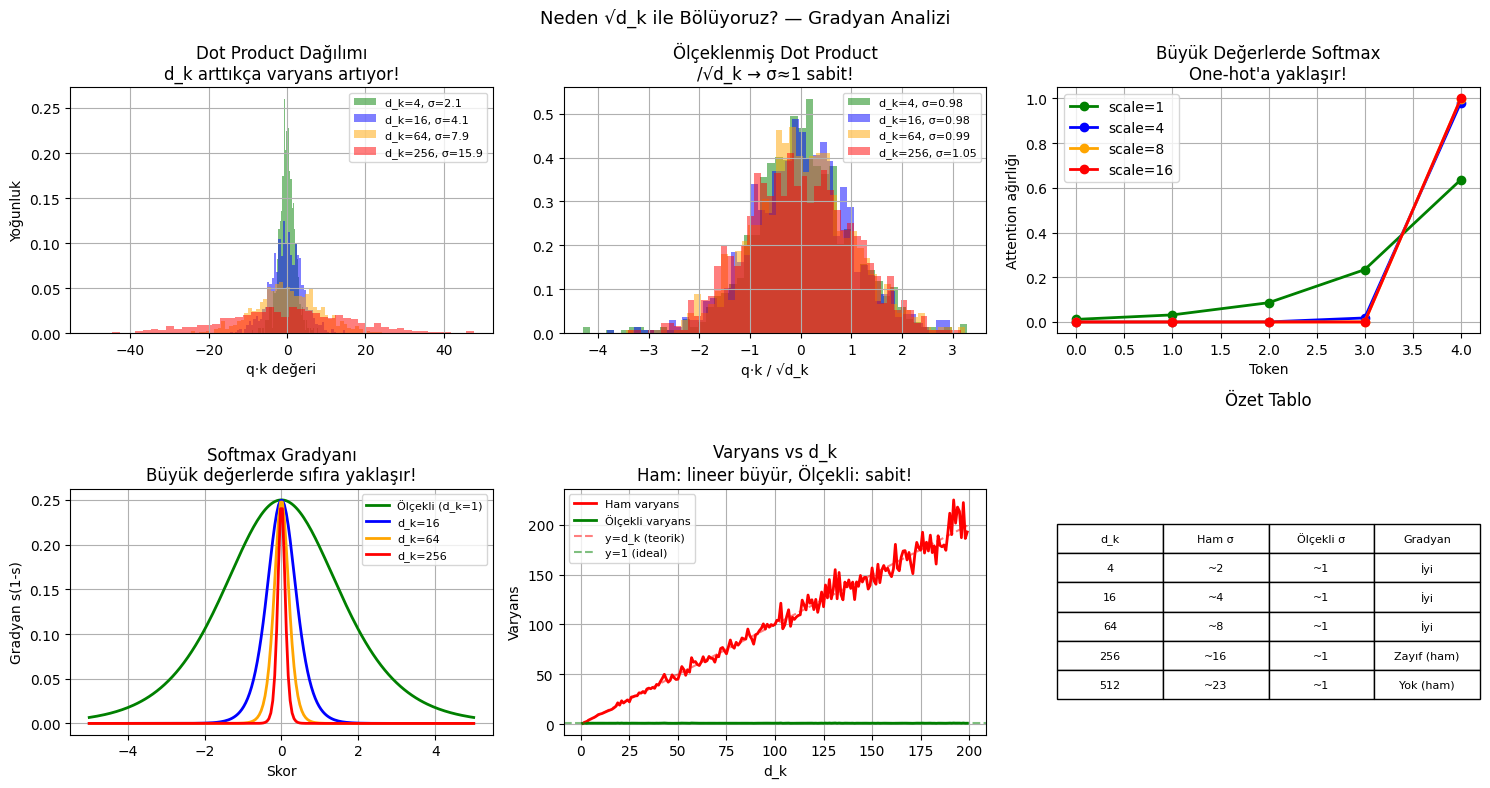

Sonuç: d_k büyüdükçe dot product varyansı d_k ile büyür
√d_k ile bölünce varyans sabit kalır → gradyanlar sağlıklı!


In [3]:
# NEDEN sqrt(d_k) İLE BÖLÜYORUZ?
# Gradyan Analizi
#
# Q ve K rastgele başlatılırsa: Q,K ~ N(0,1)
# q·k = Σ qᵢkᵢ  (d_k terim toplamı)
# E[q·k] = 0
# Var[q·k] = d_k  ← varyans d_k ile büyüyor!
#
# d_k büyük → dot product çok büyük → softmax one-hot'a yaklaşır
# → gradyan sıfıra yaklaşır → vanishing gradient!

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Farklı d_k için dot product dağılımı
d_k_values = [4, 16, 64, 256]
renkler_dk = ['green', 'blue', 'orange', 'red']

for d_k, renk in zip(d_k_values, renkler_dk):
    q = np.random.randn(1000, d_k)
    k = np.random.randn(1000, d_k)
    dots = (q * k).sum(axis=1)
    axes[0,0].hist(dots, bins=50, alpha=0.5, color=renk,
                  label=f'd_k={d_k}, σ={dots.std():.1f}', density=True)

axes[0,0].set_title("Dot Product Dağılımı\nd_k arttıkça varyans artıyor!")
axes[0,0].set_xlabel("q·k değeri")
axes[0,0].set_ylabel("Yoğunluk")
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True)

# Ölçeklenmiş dağılım
for d_k, renk in zip(d_k_values, renkler_dk):
    q = np.random.randn(1000, d_k)
    k = np.random.randn(1000, d_k)
    dots = (q * k).sum(axis=1) / np.sqrt(d_k)
    axes[0,1].hist(dots, bins=50, alpha=0.5, color=renk,
                  label=f'd_k={d_k}, σ={dots.std():.2f}', density=True)

axes[0,1].set_title("Ölçeklenmiş Dot Product\n/√d_k → σ≈1 sabit!")
axes[0,1].set_xlabel("q·k / √d_k")
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True)

# Softmax çıktısı — büyük değerlerde ne olur?
x_vals = np.array([1.0, 2.0, 3.0, 4.0, 5.0])

scales = [1, 4, 8, 16]
for scale, renk in zip(scales, renkler_dk):
    s = softmax(x_vals * scale)
    axes[0,2].plot(range(len(x_vals)), s, 'o-', color=renk,
                  linewidth=2, label=f'scale={scale}')

axes[0,2].set_title("Büyük Değerlerde Softmax\nOne-hot'a yaklaşır!")
axes[0,2].set_xlabel("Token")
axes[0,2].set_ylabel("Attention ağırlığı")
axes[0,2].legend()
axes[0,2].grid(True)

# Gradyan analizi — softmax gradyanı büyük değerlerde yok oluyor
score_range = np.linspace(-5, 5, 200)
# Tek token için softmax gradyanı: s(1-s)
for temp, renk, etiket in [(1, 'green', 'Ölçekli (d_k=1)'),
                             (4, 'blue', 'd_k=16'),
                             (8, 'orange', 'd_k=64'),
                             (16, 'red', 'd_k=256')]:
    s = 1 / (1 + np.exp(-score_range * temp))
    grad = s * (1 - s)
    axes[1,0].plot(score_range, grad, color=renk,
                  linewidth=2, label=etiket)

axes[1,0].set_title("Softmax Gradyanı\nBüyük değerlerde sıfıra yaklaşır!")
axes[1,0].set_xlabel("Skor")
axes[1,0].set_ylabel("Gradyan s(1-s)")
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True)

# Varyans vs d_k
d_k_range = np.arange(1, 200)
variances_raw = []
variances_scaled = []

for d_k in d_k_range:
    q = np.random.randn(500, d_k)
    k = np.random.randn(500, d_k)
    dots = (q * k).sum(axis=1)
    variances_raw.append(dots.var())
    variances_scaled.append((dots / np.sqrt(d_k)).var())

axes[1,1].plot(d_k_range, variances_raw, 'r-', linewidth=2, label='Ham varyans')
axes[1,1].plot(d_k_range, variances_scaled, 'g-', linewidth=2, label='Ölçekli varyans')
axes[1,1].plot(d_k_range, d_k_range, 'r--', alpha=0.5, label='y=d_k (teorik)')
axes[1,1].axhline(y=1, color='g', linestyle='--', alpha=0.5, label='y=1 (ideal)')
axes[1,1].set_title("Varyans vs d_k\nHam: lineer büyür, Ölçekli: sabit!")
axes[1,1].set_xlabel("d_k")
axes[1,1].set_ylabel("Varyans")
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True)

# Özet tablo
axes[1,2].axis('off')
özet = [
    ["d_k", "Ham σ", "Ölçekli σ", "Gradyan"],
    ["4",   "~2",    "~1",        "İyi"],
    ["16",  "~4",    "~1",        "İyi"],
    ["64",  "~8",    "~1",        "İyi"],
    ["256", "~16",   "~1",        "Zayıf (ham)"],
    ["512", "~23",   "~1",        "Yok (ham)"],
]
tablo = axes[1,2].table(
    cellText=özet[1:],
    colLabels=özet[0],
    loc='center',
    cellLoc='center'
)
tablo.scale(1, 2)
axes[1,2].set_title("Özet Tablo", pad=60)

plt.suptitle("Neden √d_k ile Bölüyoruz? — Gradyan Analizi", fontsize=13)
plt.tight_layout()
plt.show()

print("Sonuç: d_k büyüdükçe dot product varyansı d_k ile büyür")
print("√d_k ile bölünce varyans sabit kalır → gradyanlar sağlıklı!")

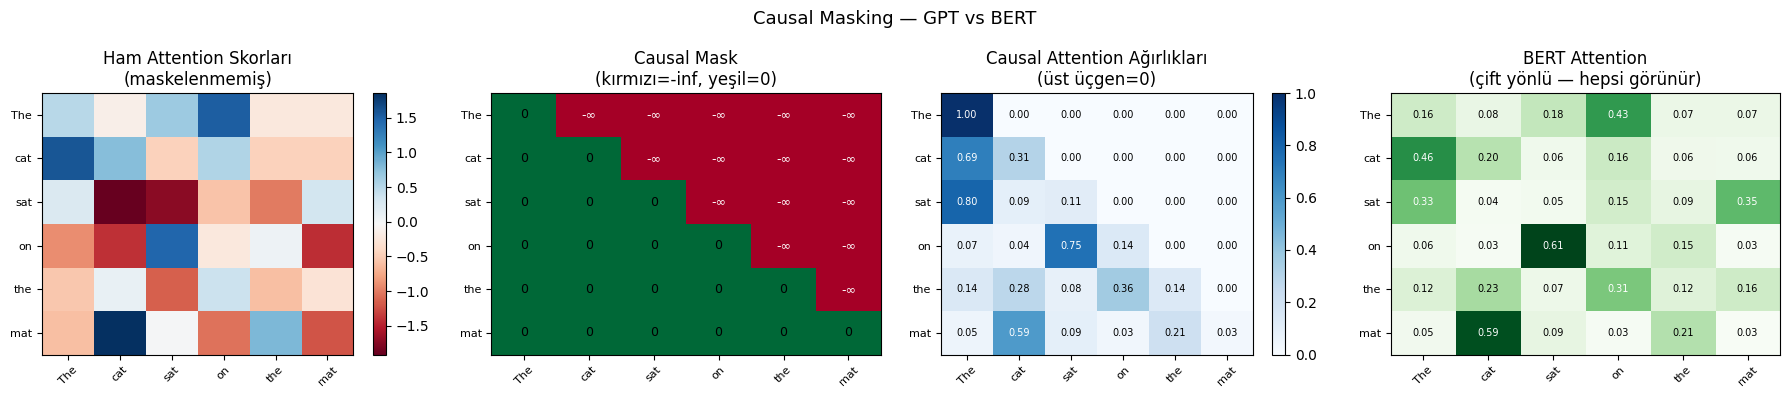

GPT (causal): Her token sadece kendinden önceki tokenlara bakabilir
BERT (bidirectional): Her token tüm tokenlara bakabilir

Neden GPT causal?
  → Metin üretiminde gelecek bilinmiyor!
  → 'The cat sat' → sonraki kelime ne?
  → Eğitimde de geleceği görmemeli (data leakage önlenir)


In [4]:
# CAUSAL MASKING — GPT NASIL GELECEK GÖRMEMESİNİ SAĞLIYOR?
#
# BERT → çift yönlü (bidirectional) — tüm tokenlara bakabilir
# GPT  → tek yönlü (causal) — sadece geçmişe bakabilir
#
# Causal mask: üst üçgen -inf, alt üçgen 0
# Softmax(-inf) = 0 → gelecek tokenlar görünmez!

seq_len = 6
kelimeler = ["The", "cat", "sat", "on", "the", "mat"]

# Causal mask oluştur
causal_mask = np.triu(np.ones((seq_len, seq_len)), k=1)
causal_mask_inf = np.where(causal_mask == 1, -np.inf, 0)

# Rastgele attention skorları
np.random.seed(42)
raw_scores = np.random.randn(seq_len, seq_len)

# Maskelenmiş skorlar
masked_scores = raw_scores + causal_mask_inf

# Softmax uygula
def softmax_2d(x):
    x_max = np.where(np.isfinite(x), x, -1e9)
    e = np.exp(x_max - x_max.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

attention_weights = softmax_2d(masked_scores)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Ham skorlar
im0 = axes[0].imshow(raw_scores, cmap='RdBu', aspect='auto')
axes[0].set_title("Ham Attention Skorları\n(maskelenmemiş)")
axes[0].set_xticks(range(seq_len))
axes[0].set_yticks(range(seq_len))
axes[0].set_xticklabels(kelimeler, rotation=45, fontsize=8)
axes[0].set_yticklabels(kelimeler, fontsize=8)
plt.colorbar(im0, ax=axes[0])

# Causal mask
mask_display = np.where(causal_mask == 1, -1, 0)
im1 = axes[1].imshow(mask_display, cmap='RdYlGn', aspect='auto')
axes[1].set_title("Causal Mask\n(kırmızı=-inf, yeşil=0)")
axes[1].set_xticks(range(seq_len))
axes[1].set_yticks(range(seq_len))
axes[1].set_xticklabels(kelimeler, rotation=45, fontsize=8)
axes[1].set_yticklabels(kelimeler, fontsize=8)

for i in range(seq_len):
    for j in range(seq_len):
        text = "-∞" if causal_mask[i,j] == 1 else "0"
        axes[1].text(j, i, text, ha='center', va='center',
                    fontsize=9, color='white' if causal_mask[i,j]==1 else 'black')

# Maskelenmiş attention
im2 = axes[2].imshow(attention_weights, cmap='Blues', aspect='auto')
axes[2].set_title("Causal Attention Ağırlıkları\n(üst üçgen=0)")
axes[2].set_xticks(range(seq_len))
axes[2].set_yticks(range(seq_len))
axes[2].set_xticklabels(kelimeler, rotation=45, fontsize=8)
axes[2].set_yticklabels(kelimeler, fontsize=8)
plt.colorbar(im2, ax=axes[2])

for i in range(seq_len):
    for j in range(seq_len):
        axes[2].text(j, i, f'{attention_weights[i,j]:.2f}',
                    ha='center', va='center', fontsize=7,
                    color='white' if attention_weights[i,j] > 0.5 else 'black')

# BERT vs GPT karşılaştırması
bert_mask = np.zeros((seq_len, seq_len))  # Hepsi görünür
bert_attention = softmax_2d(raw_scores)

axes[3].imshow(bert_attention, cmap='Greens', aspect='auto')
axes[3].set_title("BERT Attention\n(çift yönlü — hepsi görünür)")
axes[3].set_xticks(range(seq_len))
axes[3].set_yticks(range(seq_len))
axes[3].set_xticklabels(kelimeler, rotation=45, fontsize=8)
axes[3].set_yticklabels(kelimeler, fontsize=8)

for i in range(seq_len):
    for j in range(seq_len):
        axes[3].text(j, i, f'{bert_attention[i,j]:.2f}',
                    ha='center', va='center', fontsize=7,
                    color='white' if bert_attention[i,j] > 0.3 else 'black')

plt.suptitle("Causal Masking — GPT vs BERT", fontsize=13)
plt.tight_layout()
plt.show()

print("GPT (causal): Her token sadece kendinden önceki tokenlara bakabilir")
print("BERT (bidirectional): Her token tüm tokenlara bakabilir")
print()
print("Neden GPT causal?")
print("  → Metin üretiminde gelecek bilinmiyor!")
print("  → 'The cat sat' → sonraki kelime ne?")
print("  → Eğitimde de geleceği görmemeli (data leakage önlenir)")

=== SELF-ATTENTION ===
Girdi shape:  torch.Size([1, 5, 32])  (5 decoder token)
Çıktı shape:  torch.Size([1, 5, 32])  (5 token, zenginleştirilmiş)
Weights shape: torch.Size([1, 5, 5])  (5x5 — kendi içinde)

=== CROSS-ATTENTION ===
Query shape:   torch.Size([1, 5, 32])  (5 decoder token)
Context shape: torch.Size([1, 8, 32])  (8 encoder token)
Çıktı shape:   torch.Size([1, 5, 32])  (5 token, encoder'dan bilgi)
Weights shape: torch.Size([1, 5, 8])  (5x8 — decoder→encoder)


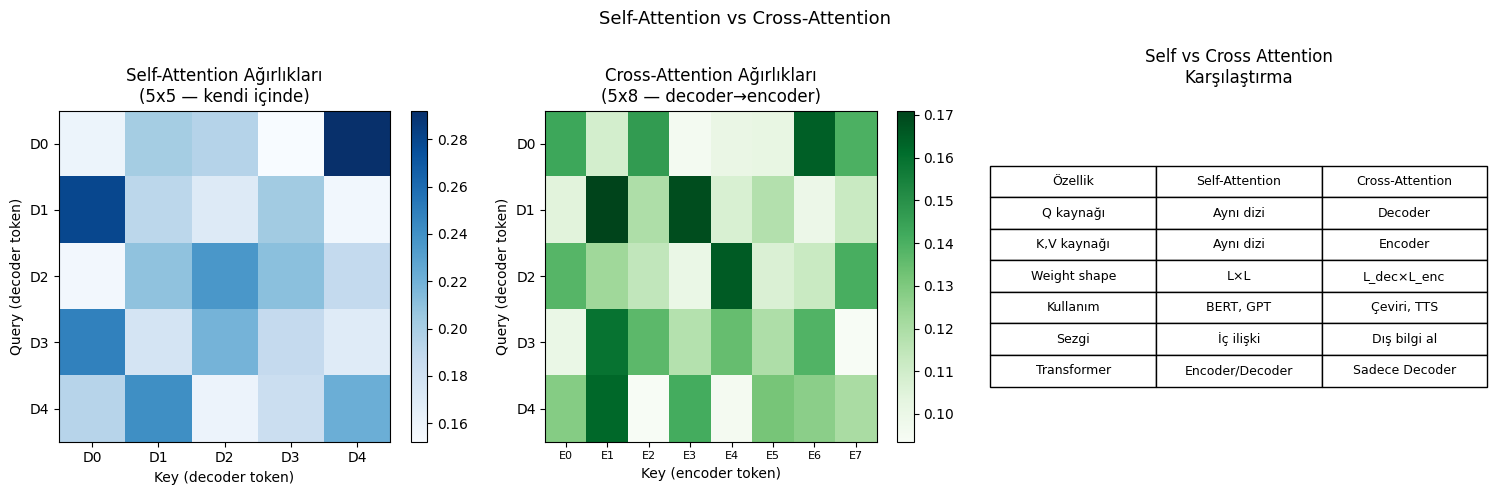

In [5]:
# CROSS-ATTENTION vs SELF-ATTENTION
#
# Self-attention:  Q, K, V hepsi aynı diziden geliyor
#                 "Cümle kendi içinde ilişki kuruyor"
#
# Cross-attention: Q bir diziden, K ve V başka bir diziden
#                 "Decoder encoder'a bakıyor"
#                 Seq2Seq, çeviri, özetleme modellerinde kullanılır

torch.manual_seed(42)

d_model = 32
num_heads = 4

# Self-attention örneği
class SelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, num_heads, batch_first=True)

    def forward(self, x):
        # Q = K = V = x (aynı dizi!)
        out, weights = self.mha(x, x, x)
        return out, weights

# Cross-attention örneği
class CrossAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, num_heads, batch_first=True)

    def forward(self, query, context):
        # Q = query dizisi, K = V = context dizisi (farklı!)
        out, weights = self.mha(query, context, context)
        return out, weights

# Test
encoder_seq = torch.randn(1, 8, d_model)   # Encoder çıktısı (8 token)
decoder_seq = torch.randn(1, 5, d_model)   # Decoder girişi (5 token)

self_attn = SelfAttention(d_model, num_heads)
cross_attn = CrossAttention(d_model, num_heads)

# Self-attention
self_out, self_weights = self_attn(decoder_seq)

# Cross-attention
cross_out, cross_weights = cross_attn(decoder_seq, encoder_seq)

print("=== SELF-ATTENTION ===")
print(f"Girdi shape:  {decoder_seq.shape}  (5 decoder token)")
print(f"Çıktı shape:  {self_out.shape}  (5 token, zenginleştirilmiş)")
print(f"Weights shape: {self_weights.shape}  (5x5 — kendi içinde)")

print("\n=== CROSS-ATTENTION ===")
print(f"Query shape:   {decoder_seq.shape}  (5 decoder token)")
print(f"Context shape: {encoder_seq.shape}  (8 encoder token)")
print(f"Çıktı shape:   {cross_out.shape}  (5 token, encoder'dan bilgi)")
print(f"Weights shape: {cross_weights.shape}  (5x8 — decoder→encoder)")

# Görselleştir
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Self-attention weights
sw = self_weights[0].detach().numpy()
im0 = axes[0].imshow(sw, cmap='Blues', aspect='auto')
axes[0].set_title(f"Self-Attention Ağırlıkları\n({sw.shape[0]}x{sw.shape[1]} — kendi içinde)")
axes[0].set_xlabel("Key (decoder token)")
axes[0].set_ylabel("Query (decoder token)")
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))
axes[0].set_xticklabels([f"D{i}" for i in range(5)])
axes[0].set_yticklabels([f"D{i}" for i in range(5)])
plt.colorbar(im0, ax=axes[0])

# Cross-attention weights
cw = cross_weights[0].detach().numpy()
im1 = axes[1].imshow(cw, cmap='Greens', aspect='auto')
axes[1].set_title(f"Cross-Attention Ağırlıkları\n({cw.shape[0]}x{cw.shape[1]} — decoder→encoder)")
axes[1].set_xlabel("Key (encoder token)")
axes[1].set_ylabel("Query (decoder token)")
axes[1].set_xticks(range(8))
axes[1].set_yticks(range(5))
axes[1].set_xticklabels([f"E{i}" for i in range(8)], fontsize=8)
axes[1].set_yticklabels([f"D{i}" for i in range(5)])
plt.colorbar(im1, ax=axes[1])

# Mimari karşılaştırma
axes[2].axis('off')
karşılaştırma = [
    ["Özellik", "Self-Attention", "Cross-Attention"],
    ["Q kaynağı", "Aynı dizi", "Decoder"],
    ["K,V kaynağı", "Aynı dizi", "Encoder"],
    ["Weight shape", "L×L", "L_dec×L_enc"],
    ["Kullanım", "BERT, GPT", "Çeviri, TTS"],
    ["Sezgi", "İç ilişki", "Dış bilgi al"],
    ["Transformer", "Encoder/Decoder", "Sadece Decoder"],
]

tablo = axes[2].table(
    cellText=karşılaştırma[1:],
    colLabels=karşılaştırma[0],
    loc='center',
    cellLoc='center'
)
tablo.scale(1.2, 2.2)
tablo.auto_set_font_size(False)
tablo.set_fontsize(9)
axes[2].set_title("Self vs Cross Attention\nKarşılaştırma", pad=20)

plt.suptitle("Self-Attention vs Cross-Attention", fontsize=13)
plt.tight_layout()
plt.show()